#### **Analysing the models using bigger training, validation and test dataset.**

- Encountered an error which was occuring due to channels.
- Need to find and resolve the issue before continuing.

In [1]:
import os
from PIL import Image
import pandas as pd

def check_image_channels(folder_path):
    # List to store image details
    image_data = []

    # Loop through all files in the folder
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        
        try:
            with Image.open(file_path) as img:
                # Get the mode and size
                mode = img.mode
                channels = {
                    "1": 1,  # 1-bit pixels, black and white
                    "L": 1,  # 8-bit pixels, grayscale
                    "LA": 2,  # Grayscale + Alpha
                    "RGB": 3,  # True color
                    "RGBA": 4,  # True color with alpha
                    "CMYK": 4,  # Cyan, Magenta, Yellow, Black
                    "P": 1,  # Palette-based
                }.get(mode, "Unknown")
                
                # Append to the list
                image_data.append({
                    "File Path": file_path,
                    "Image Mode": mode,
                    "Channels": channels,
                    "Flagged": channels == 2
                })

        except Exception as e:
            # If there's an error, log it
            image_data.append({
                "File Path": file_path,
                "Image Mode": "Error",
                "Channels": "Error",
                "Flagged": False,
                "Error": str(e),
            })

    # Create a DataFrame
    df = pd.DataFrame(image_data)
    return df

# Set your folder path
folder_path = "data/RawDataset/Cat"

# Call the function
df = check_image_channels(folder_path)

# Print the DataFrame
display(df[df['Channels'] == 'Error'])
display(df['Channels'].unique())
# Set your folder path
folder_path = "data/RawDataset/Dog"

# Call the function
df = check_image_channels(folder_path)

# Print the DataFrame
display(df[df['Channels'] == 'Error'])
display(df['Channels'].unique())


,File Path,Image Mode,Channels,Flagged


array([3, 1], dtype=int64)

c:\Users\DELL\Desktop\Conestoga\AIML\FoundationsMachineLearningFramework\git\CSCN8010\venv\tensorflow_cpu\Lib\site-packages\PIL\TiffImagePlugin.py:935: UserWarning: Truncated File Read
  warnings.warn(str(msg))


,File Path,Image Mode,Channels,Flagged


array([3, 1, 4], dtype=int64)

In [2]:
from PL3DatasetCreator import PL3DatasetCreator

datasetCreator = PL3DatasetCreator(newdirName= "Large")
datasetCreator.createDataset(5000, 3000, 75, 15)

8000 8500 8800


Found 6000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 600 files belonging to 2 classes.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 89, 89, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_

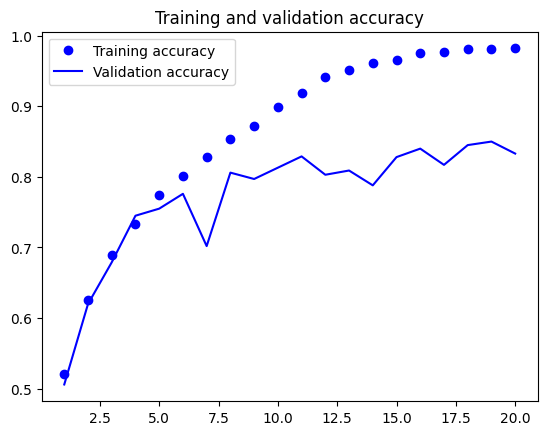

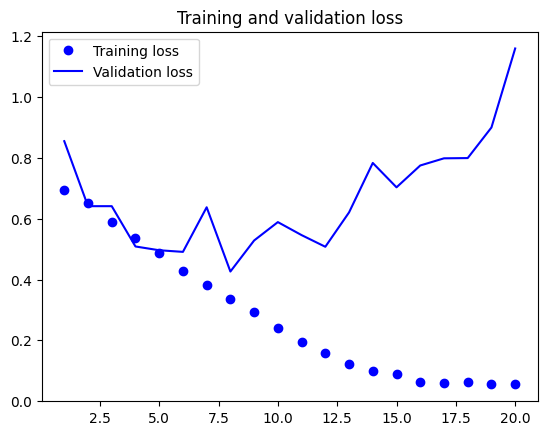

In [3]:
from CustomNeuralNetwork2Augmented import CustomNeuralNetwork2Augmented
from NeuralNetworkEvaluator import NeuralNetworkEvaluator
from NeuralNetworkTestEvaluator import NeuralNetworkTestEvaluator


valuator = NeuralNetworkEvaluator("data/Large")
customNN = CustomNeuralNetwork2Augmented()
customNN.model.summary()
customModel = customNN.model
valuator.trainandvalidate(customModel, "Large","customNN2Augmented", 20)

Found 6000 files belonging to 2 classes.
<_BatchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_MapDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Found 1000 files belonging to 2 classes.
<_BatchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_MapDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Found 600 files belonging to 2 classes.
<_BatchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_MapDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), d

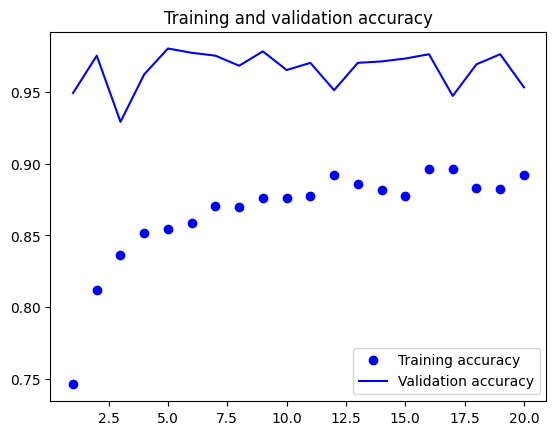

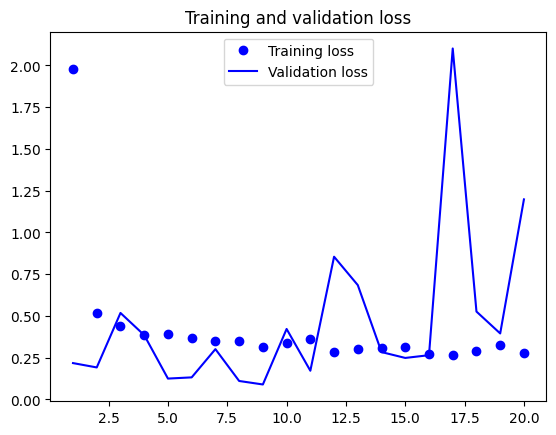

In [4]:
from CustomVGG16Aug import CustomVGG16Aug
from NeuralNetworkEvaluatorVGG import NeuralNetworkEvaluatorVGG
from NeuralNetworkTestEvaluatorVGG import NeuralNetworkTestEvaluatorVGG


valuator = NeuralNetworkEvaluatorVGG("data/Large")
customVGG16Aug = CustomVGG16Aug()
customVGG16Aug.model.summary()
customModelVGG16Aug = customVGG16Aug.model
valuator.trainandvalidate(customModelVGG16Aug, "Large","CustomVGG16Aug",20)

#### **Test Evaluation for Custom Augmented Model**

Found 600 files belonging to 2 classes.
Model Evaluation Results:
--------------------------------------------------
19/19 [==============================] - 4s 208ms/step - loss: 0.4345 - accuracy: 0.8067 - auc: 0.8886 - precision: 0.8194 - recall: 0.7867

Test Accuracy: 0.8067
1/1 [==============================] - 0s 228ms/step


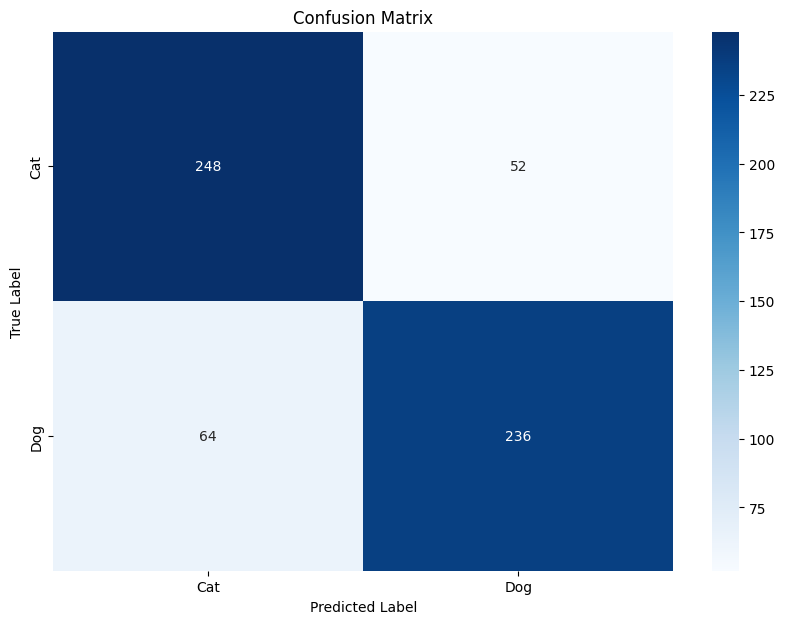

1/1 [==============================] - 0s 178ms/step

Classification Report:
              precision    recall  f1-score   support

         Cat       0.79      0.83      0.81       300
         Dog       0.82      0.79      0.80       300

    accuracy                           0.81       600
   macro avg       0.81      0.81      0.81       600
weighted avg       0.81      0.81      0.81       600

1/1 [==============================] - 0s 165ms/step


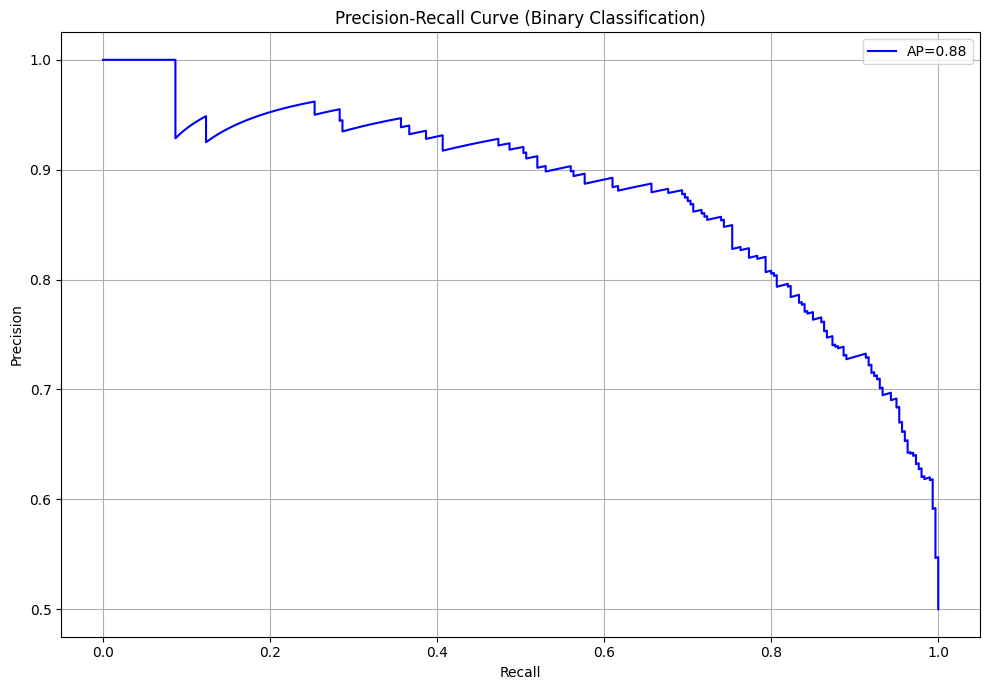

1/1 [==============================] - 0s 291ms/step
Actual : 0 Predicted: 1


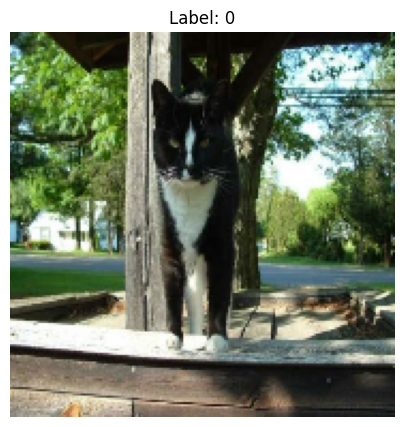

Actual : 0 Predicted: 1


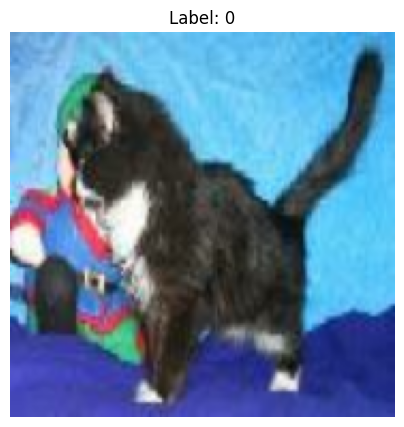

Actual : 0 Predicted: 1


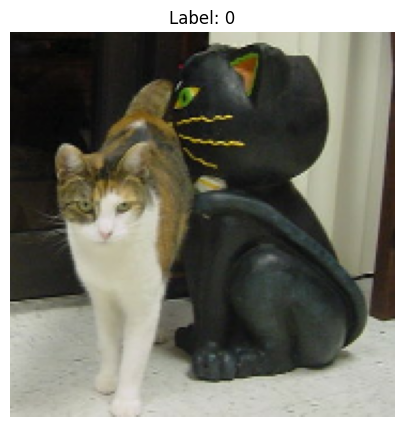

Actual : 0 Predicted: 1


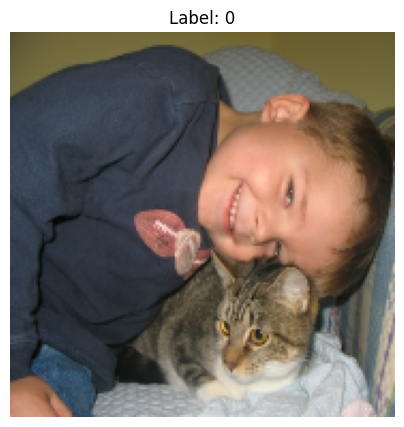

Actual : 0 Predicted: 1


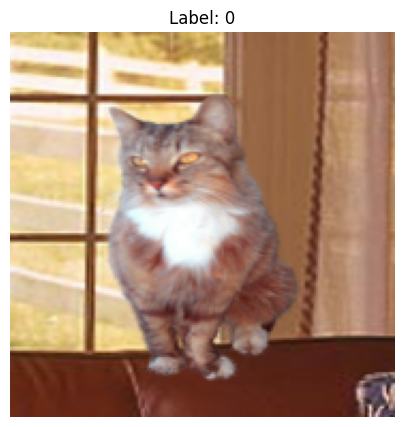

Actual : 0 Predicted: 1


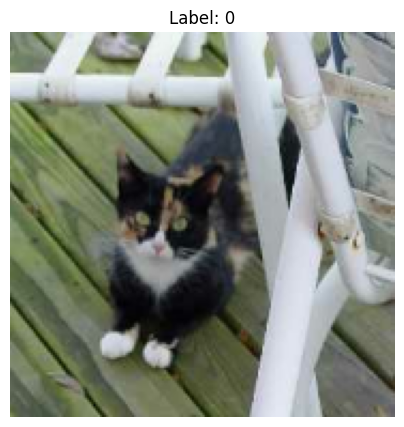

1/1 [==============================] - 0s 215ms/step
Actual : 0 Predicted: 1


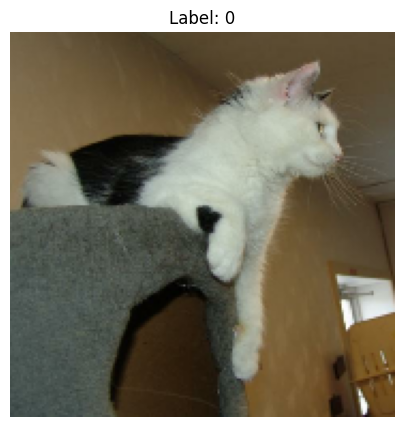

Actual : 0 Predicted: 1


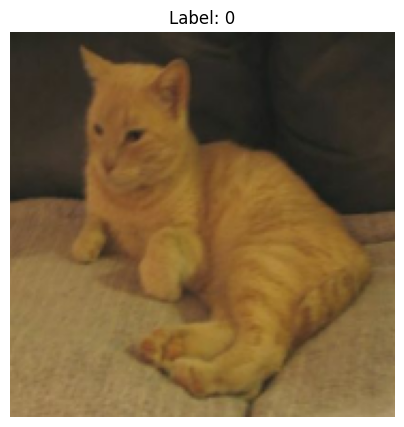

Actual : 0 Predicted: 1


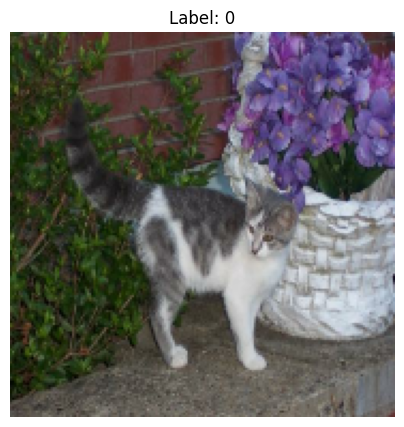

Actual : 0 Predicted: 1


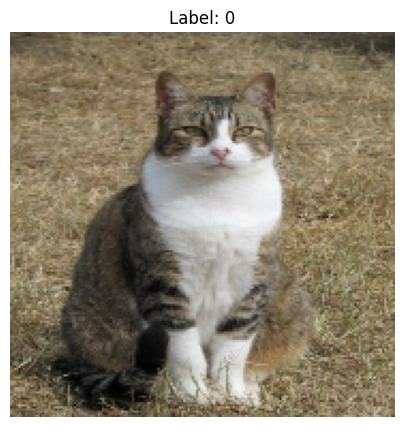

Actual : 0 Predicted: 1


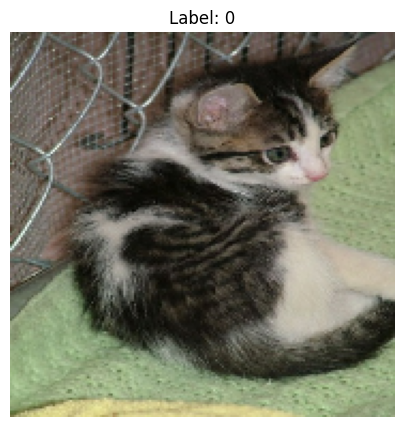

Actual : 0 Predicted: 1


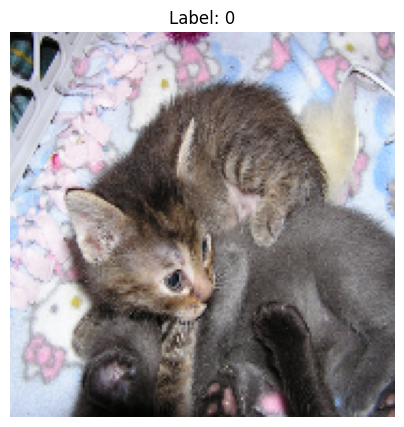

Actual : 0 Predicted: 1


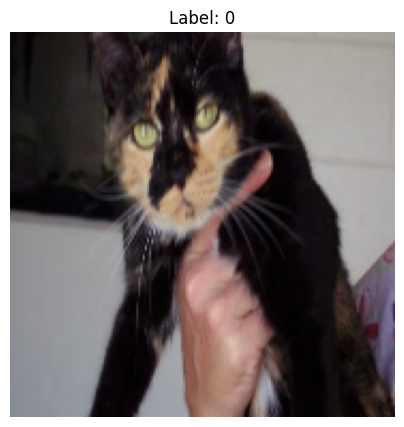

1/1 [==============================] - 0s 212ms/step
Actual : 0 Predicted: 1


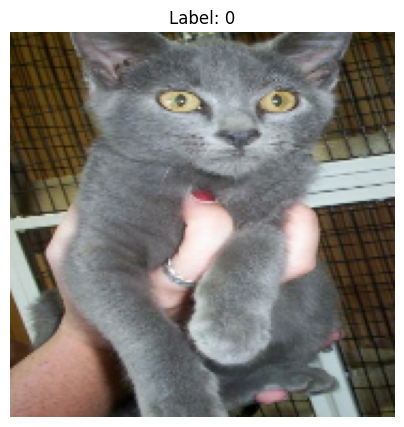

1/1 [==============================] - 0s 209ms/step
Actual : 0 Predicted: 1


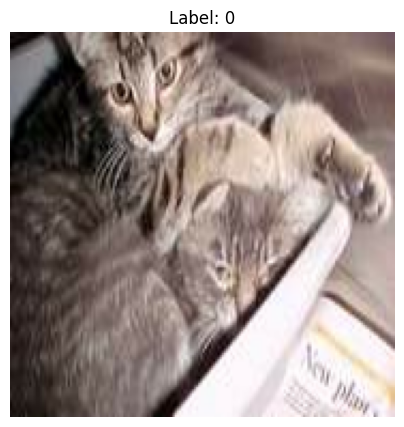

1/1 [==============================] - 0s 208ms/step
Actual : 1 Predicted: 0


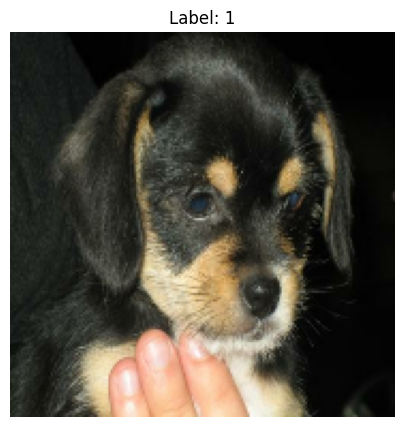

1/1 [==============================] - 0s 219ms/step
Actual : 1 Predicted: 0


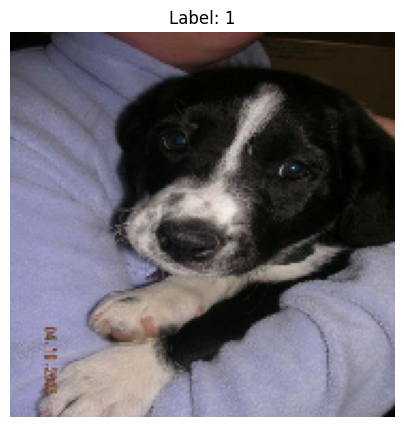

1/1 [==============================] - 0s 163ms/step


{'accuracy': 0.8066666722297668,
 'confusion_matrix': array([[248,  52],
        [ 64, 236]], dtype=int64),
 'classification_metrics': {'Cat': {'precision': 0.7948717948717948,
   'recall': 0.8266666666666667,
   'f1-score': 0.8104575163398693,
   'support': 300.0},
  'Dog': {'precision': 0.8194444444444444,
   'recall': 0.7866666666666666,
   'f1-score': 0.802721088435374,
   'support': 300.0},
  'accuracy': 0.8066666666666666,
  'macro avg': {'precision': 0.8071581196581197,
   'recall': 0.8066666666666666,
   'f1-score': 0.8065893023876216,
   'support': 600.0},
  'weighted avg': {'precision': 0.8071581196581196,
   'recall': 0.8066666666666666,
   'f1-score': 0.8065893023876216,
   'support': 600.0}}}

In [5]:
from NeuralNetworkTestEvaluator import NeuralNetworkTestEvaluator
from tensorflow import keras


test_model_cnn2augmented_large = keras.models.load_model(
    "./models/Large/customNN2Augmented/11-23-02-39/model.keras")
cnn2AugmentedNanoTestEvaluator = NeuralNetworkTestEvaluator("data/Large", test_model_cnn2augmented_large, 13)
cnn2AugmentedNanoTestEvaluator.evaluate_model()

- We can see that after training in 6x of the nano dataset we achieved a 5% increase in accuracy from what we saw earlier.
- The precision recall curve has also improved from AUC increased from 71 to 88
- Examining the misclassified images we can see that shades or colors of the animals might be drastically affecting accuracy.

#### **Test Evaluation for VGG-16 Augmented Trained model**

Found 600 files belonging to 2 classes.
<_BatchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_MapDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Model Evaluation Results:
--------------------------------------------------
19/19 [==============================] - 65s 3s/step - loss: 0.1346 - accuracy: 0.9817 - auc: 0.9925 - precision_1: 0.9833 - recall_1: 0.9800

Test Accuracy: 0.9817
1/1 [==============================] - 3s 3s/step


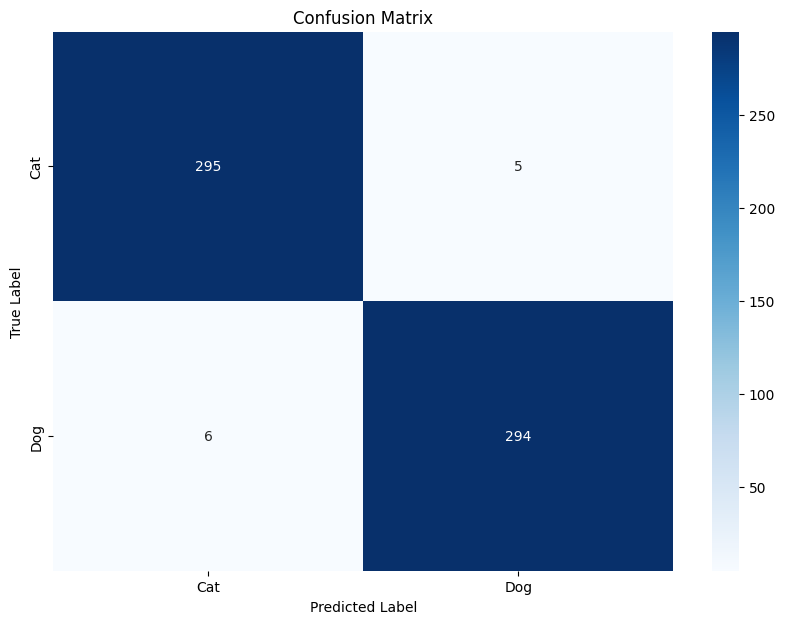

1/1 [==============================] - 3s 3s/step

Classification Report:
              precision    recall  f1-score   support

         Cat       0.98      0.98      0.98       300
         Dog       0.98      0.98      0.98       300

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600

1/1 [==============================] - 3s 3s/step


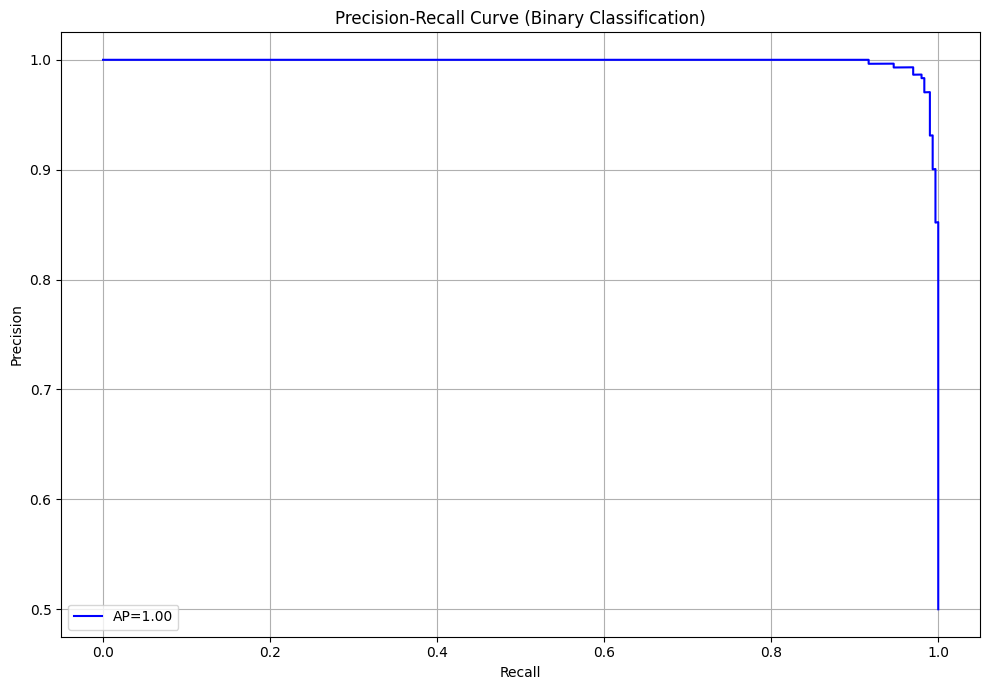

1/1 [==============================] - 4s 4s/step
Actual : 0 Predicted: 1


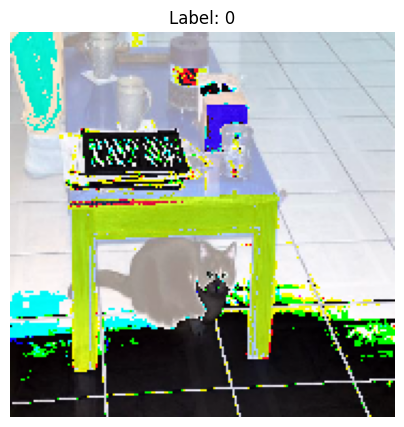

1/1 [==============================] - 4s 4s/step
Actual : 0 Predicted: 1


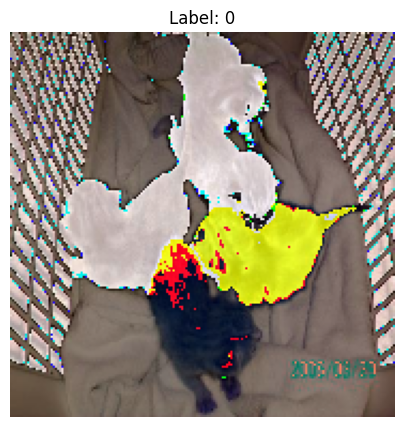

1/1 [==============================] - 4s 4s/step
Actual : 0 Predicted: 1


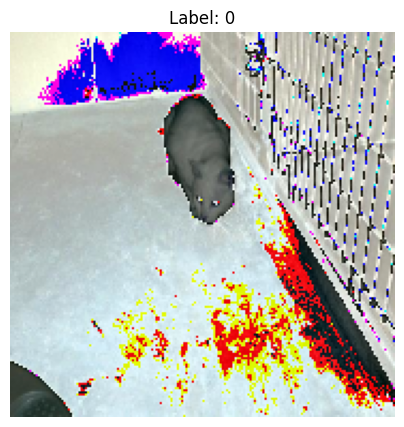

1/1 [==============================] - 4s 4s/step
Actual : 0 Predicted: 1


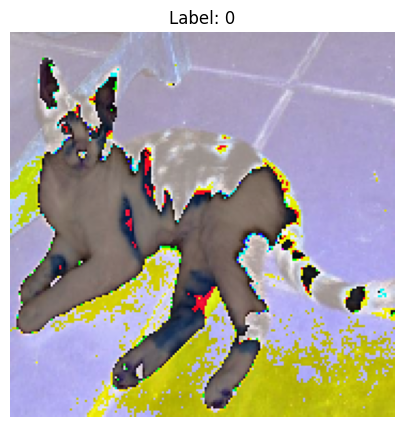

1/1 [==============================] - 4s 4s/step
Actual : 0 Predicted: 1


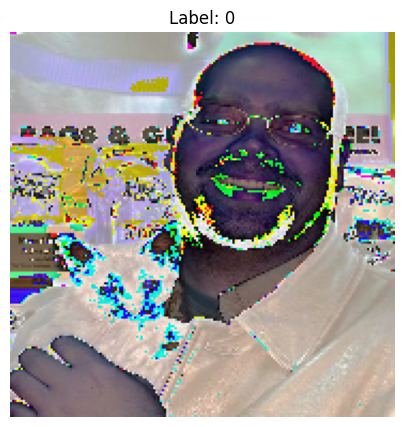

1/1 [==============================] - 4s 4s/step
Actual : 1 Predicted: 0


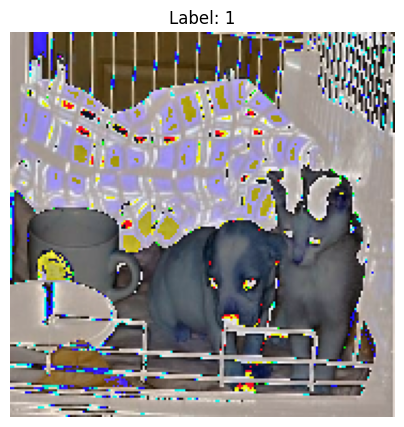

1/1 [==============================] - 4s 4s/step
Actual : 1 Predicted: 0


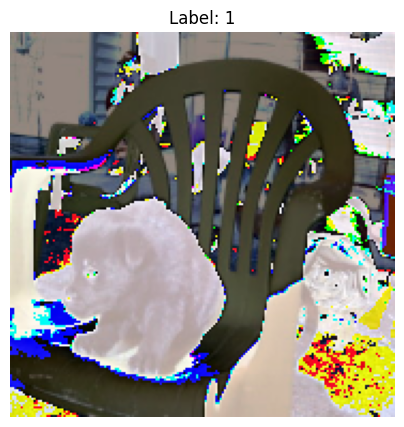

1/1 [==============================] - 4s 4s/step
Actual : 1 Predicted: 0


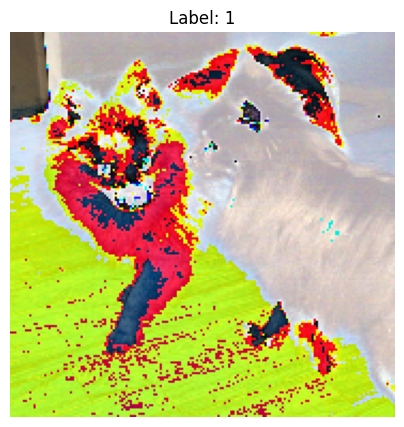

Actual : 1 Predicted: 0


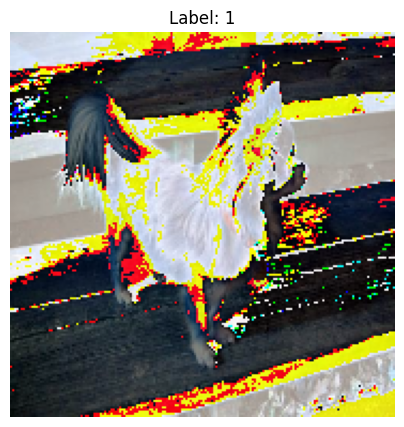

1/1 [==============================] - 4s 4s/step
Actual : 1 Predicted: 0


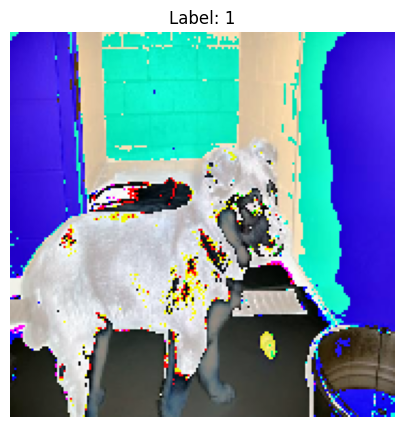

Actual : 1 Predicted: 0


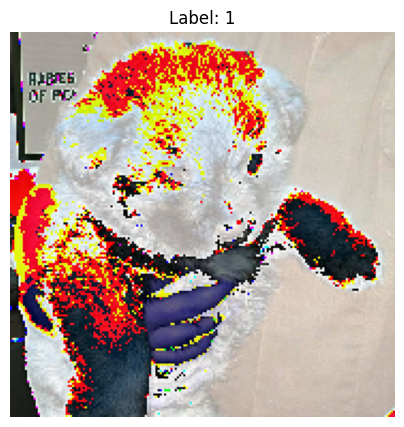

1/1 [==============================] - 3s 3s/step


{'accuracy': 0.9816666841506958,
 'confusion_matrix': array([[295,   5],
        [  6, 294]], dtype=int64),
 'classification_metrics': {'Cat': {'precision': 0.9800664451827242,
   'recall': 0.9833333333333333,
   'f1-score': 0.9816971713810315,
   'support': 300.0},
  'Dog': {'precision': 0.9832775919732442,
   'recall': 0.98,
   'f1-score': 0.9816360601001669,
   'support': 300.0},
  'accuracy': 0.9816666666666667,
  'macro avg': {'precision': 0.9816720185779841,
   'recall': 0.9816666666666667,
   'f1-score': 0.9816666157405992,
   'support': 600.0},
  'weighted avg': {'precision': 0.9816720185779844,
   'recall': 0.9816666666666667,
   'f1-score': 0.9816666157405992,
   'support': 600.0}}}

In [1]:
from NeuralNetworkTestEvaluatorVGG import NeuralNetworkTestEvaluatorVGG
from tensorflow import keras


test_model_vgg_aug_large = keras.models.load_model(
    "./models/Large/customVGG16Aug/11-23-03-40/model.keras")
vggAugTestEvaluator = NeuralNetworkTestEvaluatorVGG("data/Large", test_model_vgg_aug_large, 13)
vggAugTestEvaluator.evaluate_model()

- We got a really good increase in accuracy after training on the larger dataset. 90% to 98.2%.
- The area under curve for precision recall curve increased from 96 to ~1 which is close to perfection.
- We can see that for high precision we are also able to achieve high recall.
- F1 score is 98% which is really good.
- Examining the misclassified images we can see that some of the images are pictures with both animals or with humans. This can be solved by adding more such images with labels during training.